---
date: "2026-09-13"
date-modified: last-modified
format:
  html:
    toc: true
---


# Linear Independence, Basis, and Dimension

## 1\. Operations on Subspaces

Let $K$ be a [field](field.ipynb) and $E$ a [vector space](vector-spaces.ipynb) over $K$. Given [subspaces](vector-spaces.ipynb#def-subspace) of $E$, we can construct new subspaces via **intersection** and **sum**.

### 1\.1\. Intersection of Subspaces

::: {#prp-intersection-subspace}
## Intersection of Subspaces

The intersection of any family of subspaces of $E$ is itself a subspace of $E$.
:::

::: {.callout-tip collapse="true"}
## Proof of @prp-intersection-subspace

Let $\{E_i\}_{i \in I}$ be a family of subspaces of $E$, and let $F = \bigcap_{i \in I} E_i$. We verify the [subspace criterion](vector-spaces.ipynb#prp-subspace-criterion):

1. **Closure under addition:** If $u, v \in F$, then $u, v \in E_i$ for every $i \in I$. Since each $E_i$ is a subspace, $u + v \in E_i$ for every $i$. Hence $u + v \in F$.
2. **Closure under scalar multiplication:** If $c \in K$ and $u \in F$, then $u \in E_i$ for every $i$. Since each $E_i$ is a subspace, $cu \in E_i$ for every $i$. Hence $cu \in F$.

$\blacksquare$
:::


### 1\.2\. Sum of Subspaces

::: {#def-sum-subspaces}
## Sum of Subspaces

Let $E_1$ and $E_2$ be subspaces of $E$. Their **sum** is defined as:

$$E_1 + E_2 = \{x_1 + x_2 \mid x_1 \in E_1,\; x_2 \in E_2\}$$

That is, $E_1 + E_2$ is the set of all possible sums of one vector from $E_1$ and one vector from $E_2$.
:::

::: {#prp-sum-is-subspace}
## Sum of Subspaces is a Subspace

If $E_1$ and $E_2$ are subspaces of $E$, then $E_1 + E_2$ is also a subspace of $E$.
:::

::: {.callout-tip collapse="true"}
## Proof of @prp-sum-is-subspace

We verify the [subspace criterion](vector-spaces.ipynb#prp-subspace-criterion):

**Closure under addition.** Take two elements of $E_1 + E_2$, say $x_1 + x_2$ and $x'_1 + x'_2$ where $x_1, x'_1 \in E_1$ and $x_2, x'_2 \in E_2$. Their sum is:

$$(x_1 + x_2) + (x'_1 + x'_2) = (x_1 + x'_1) + (x_2 + x'_2)$$

by commutativity and associativity of addition. Since $E_1$ is a subspace, $x_1 + x'_1 \in E_1$. Since $E_2$ is a subspace, $x_2 + x'_2 \in E_2$. Hence the sum lies in $E_1 + E_2$.

**Closure under scalar multiplication.** For $\alpha \in K$ and $x_1 + x_2 \in E_1 + E_2$:

$$\alpha(x_1 + x_2) = \alpha x_1 + \alpha x_2$$

by distributivity. Since $E_1$ is a subspace, $\alpha x_1 \in E_1$. Since $E_2$ is a subspace, $\alpha x_2 \in E_2$. Hence $\alpha(x_1 + x_2) \in E_1 + E_2$.

$\blacksquare$
:::

::: {.callout-warning}
## Sum $\neq$ Union
The **sum** $E_1 + E_2$ is generally much larger than the **union** $E_1 \cup E_2$. For example, if $E_1$ and $E_2$ are two distinct lines through the origin in $\mathbb{R}^3$, then:

- $E_1 \cap E_2 = \{0\}$ (just the origin),
- $E_1 \cup E_2$ is two lines (not a subspace!),
- $E_1 + E_2$ is the entire plane spanned by the two lines.

If $E_1$ and $E_2$ happen to lie along the same direction, then $E_1 = E_2$ and $E_1 + E_2 = E_1$.
:::

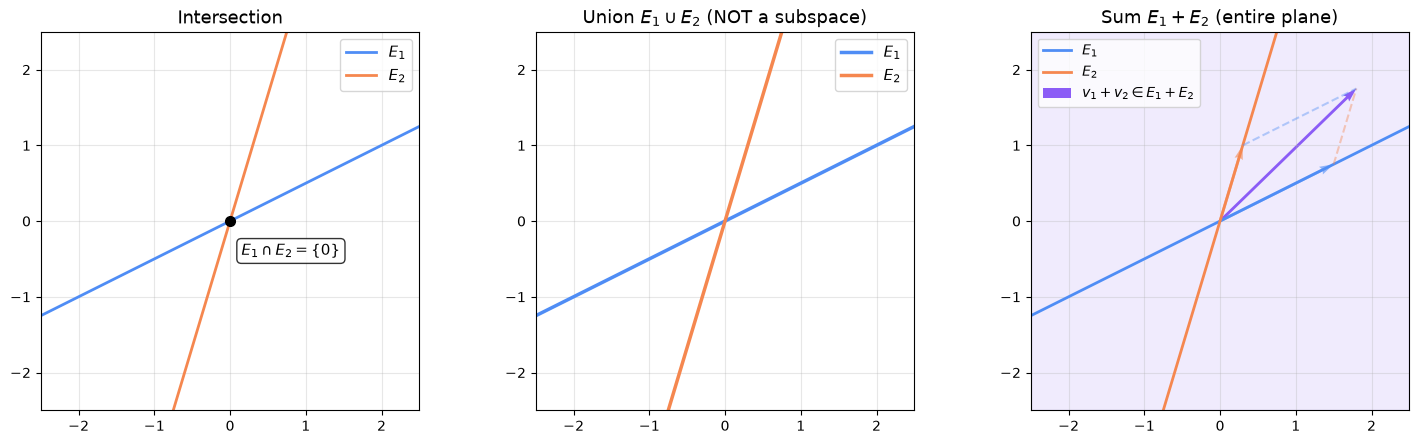

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import warnings; warnings.filterwarnings('ignore')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Two lines through the origin
t = np.linspace(-2.5, 2.5, 100)
# E1: direction (1, 0.5), E2: direction (0.3, 1)
d1 = np.array([1, 0.5])
d2 = np.array([0.3, 1])

# --- Panel 1: Intersection ---
ax = axes[0]
ax.plot(t * d1[0], t * d1[1], color='#4f8df5', linewidth=2, label='$E_1$')
ax.plot(t * d2[0], t * d2[1], color='#f5874f', linewidth=2, label='$E_2$')
ax.plot(0, 0, 'ko', markersize=7, zorder=5)
ax.annotate('$E_1 \\cap E_2 = \\{0\\}$', (0.15, -0.45), fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.legend(fontsize=11); ax.set_title('Intersection', fontsize=13)

# --- Panel 2: Union ---
ax = axes[1]
ax.plot(t * d1[0], t * d1[1], color='#4f8df5', linewidth=2.5, label='$E_1$')
ax.plot(t * d2[0], t * d2[1], color='#f5874f', linewidth=2.5, label='$E_2$')
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.legend(fontsize=11); ax.set_title('Union $E_1 \\cup E_2$ (NOT a subspace)', fontsize=13)

# --- Panel 3: Sum (= the whole plane R²) ---
ax = axes[2]
ax.fill_between([-2.5, 2.5], -2.5, 2.5, color='#8b5cf6', alpha=0.12)
ax.plot(t * d1[0], t * d1[1], color='#4f8df5', linewidth=2, label='$E_1$')
ax.plot(t * d2[0], t * d2[1], color='#f5874f', linewidth=2, label='$E_2$')
# show a sample sum vector
v1 = 1.5 * d1; v2 = 1.0 * d2; vs = v1 + v2
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
          color='#4f8df5', linewidth=1.5, alpha=0.6)
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
          color='#f5874f', linewidth=1.5, alpha=0.6)
ax.quiver(0, 0, vs[0], vs[1], angles='xy', scale_units='xy', scale=1,
          color='#8b5cf6', linewidth=2.5, label='$v_1 + v_2 \\in E_1+E_2$')
ax.plot([v1[0], vs[0]], [v1[1], vs[1]], '--', color='#f5874f', alpha=0.4)
ax.plot([v2[0], vs[0]], [v2[1], vs[1]], '--', color='#4f8df5', alpha=0.4)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper left')
ax.set_title('Sum $E_1 + E_2$ (entire plane)', fontsize=13)

plt.tight_layout()
plt.show()


## 2\. Linear Combinations and Span

::: {#def-linear-combination}
## Linear Combination

Let $x_1, \dots, x_k \in E$ and $\alpha_1, \dots, \alpha_k \in K$. The expression

$$\alpha_1 x_1 + \alpha_2 x_2 + \cdots + \alpha_k x_k$$

is called a **linear combination** of $x_1, \dots, x_k$ with coefficients $\alpha_1, \dots, \alpha_k$.
:::

---

::: {#def-span}
## Span

Let $S \subseteq E$ be any subset (finite or infinite). The **span** of $S$ is the set of all (finite) linear combinations of elements of $S$:

$$\operatorname{span}(S) = \left\{\alpha_1 x_1 + \cdots + \alpha_k x_k \;\middle|\; k \in \mathbb{N},\; x_1, \dots, x_k \in S,\; \alpha_1, \dots, \alpha_k \in K\right\}$$

When $S = \{x_1, \dots, x_k\}$ is finite, we write $\operatorname{span}(x_1, \dots, x_k)$.
:::

::: {#prp-span-is-subspace}
## Span is a Subspace

For any subset $S \subseteq E$, $\operatorname{span}(S)$ is a subspace of $E$.
:::

::: {.callout-tip collapse="true"}
## Proof of @prp-span-is-subspace

We verify the [subspace criterion](vector-spaces.ipynb#prp-subspace-criterion):

**Closure under addition.** Let $u = \alpha_1 x_1 + \cdots + \alpha_k x_k$ and $v = \beta_1 x_1 + \cdots + \beta_k x_k$ be in $\operatorname{span}(S)$ (using the same vectors $x_i$ by possibly setting some coefficients to zero). Then:

$$u + v = (\alpha_1 + \beta_1)x_1 + \cdots + (\alpha_k + \beta_k)x_k \in \operatorname{span}(S)$$

**Closure under scalar multiplication.** For $\alpha \in K$:

$$\alpha u = (\alpha \alpha_1)x_1 + \cdots + (\alpha \alpha_k)x_k \in \operatorname{span}(S)$$

by distributivity and the compatibility of scalar multiplication.

$\blacksquare$
:::

::: {.callout-note}
## Intuition: Span Generalises the Sum of Subspaces
The [sum of two subspaces](#def-sum-subspaces) is a special case: if $E_1 = \operatorname{span}(u)$ and $E_2 = \operatorname{span}(v)$ are two lines through the origin, then $E_1 + E_2 = \operatorname{span}(u, v)$, which is the plane they determine (assuming $u$ and $v$ are not collinear).

Even when $S$ is infinite, $\operatorname{span}(S)$ only involves *finite* linear combinations. Each element uses finitely many vectors from $S$, but there is no bound on *which* or *how many* vectors are used.
:::


## 3\. Linear Independence and Dependence

::: {#def-linear-independence}
## Linear Independence

A subset $S \subseteq E$ is called **linearly independent** if no non-trivial finite linear combination of elements of $S$ equals the zero vector. That is, whenever

$$\alpha_1 x_1 + \alpha_2 x_2 + \cdots + \alpha_m x_m = 0$$

for distinct $x_1, \dots, x_m \in S$ and $\alpha_1, \dots, \alpha_m \in K$, it must follow that $\alpha_1 = \alpha_2 = \cdots = \alpha_m = 0$.

Otherwise, $S$ is called **linearly dependent**.
:::

::: {.callout-note}
## Intuition: Dependence Means Redundancy
Linear dependence of $S$ means some $x_j \in S$ can be expressed as a linear combination of the remaining elements. Indeed, if $\alpha_1 x_1 + \cdots + \alpha_m x_m = 0$ with, say, $\alpha_j \neq 0$, then:

$$x_j = -\sum_{i \neq j} \frac{\alpha_i}{\alpha_j}\, x_i$$

So $x_j$ is "redundant" — it already lies in the span of the others.
:::

---

### 3\.1\. Key Observations

**Observation 1.** If $0 \in S$, then $S$ is linearly dependent.

The zero vector satisfies $1 \cdot 0 = 0$, which is a non-trivial linear relation (the coefficient $1 \neq 0$).

**Observation 2.** If $S$ is linearly dependent and $S \subseteq T$, then $T$ is also linearly dependent.

Any non-trivial linear relation among elements of $S$ is also a relation among elements of $T$, since $S \subseteq T$.

**Observation 3.** If $S$ is linearly independent and $\emptyset \neq T \subseteq S$, then $T$ is also linearly independent.

This is the contrapositive of Observation 2: if $T$ were dependent, then $S \supseteq T$ would also be dependent, contradicting the independence of $S$.


## 4\. The Exchange Lemma (Steinitz)

This elementary but fundamental result underlies the entire theory of dimension. Its proof technique — systematically swapping generators for independent vectors — recurs throughout linear algebra.

::: {#lem-exchange}
## Exchange Lemma

Suppose $\{y_1, \dots, y_m\}$ is linearly independent and each $y_i \in \operatorname{span}(x_1, \dots, x_n)$. Then:

$$m \le n$$

In words: in the span of $n$ vectors, one cannot find more than $n$ linearly independent vectors.
:::

::: {.callout-tip collapse="true"}
## Proof of @lem-exchange

We proceed by successively "exchanging" the $x_i$'s for $y_i$'s.

**Step 1.** Since $y_1 \in \operatorname{span}(x_1, \dots, x_n)$, we can write:

$$y_1 = \alpha_1 x_1 + \cdots + \alpha_n x_n$$

Since the $y_i$'s are linearly independent, $y_1 \neq 0$ (a set containing $0$ cannot be independent). Therefore at least one $\alpha_i \neq 0$. Without loss of generality, say $\alpha_1 \neq 0$. Solving for $x_1$:

$$x_1 = \frac{1}{\alpha_1}\, y_1 - \sum_{i=2}^{n} \frac{\alpha_i}{\alpha_1}\, x_i$$

This shows $x_1 \in \operatorname{span}(y_1, x_2, \dots, x_n)$, and consequently:

$$\operatorname{span}(x_1, x_2, \dots, x_n) = \operatorname{span}(y_1, x_2, \dots, x_n)$$

**Step 2.** Since $y_2 \in \operatorname{span}(x_1, \dots, x_n) = \operatorname{span}(y_1, x_2, \dots, x_n)$, we write:

$$y_2 = \beta_1 y_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

Again $y_2 \neq 0$, so not all $\beta_i$ are zero. Moreover, at least one of $\beta_2, \dots, \beta_n$ must be non-zero, because if all of $\beta_2, \dots, \beta_n$ were zero, then $y_2 = \beta_1 y_1$, contradicting the linear independence of $\{y_1, y_2\}$ (a subset of the independent set $\{y_1, \dots, y_m\}$). Say $\beta_2 \neq 0$. Solving for $x_2$:

$$x_2 \in \operatorname{span}(y_1, y_2, x_3, \dots, x_n)$$

and therefore $\operatorname{span}(x_1, \dots, x_n) = \operatorname{span}(y_1, y_2, x_3, \dots, x_n)$.

**Continuing.** Repeating this argument, after $k$ steps we have:

$$\operatorname{span}(x_1, \dots, x_n) = \operatorname{span}(y_1, \dots, y_k, x_{k+1}, \dots, x_n)$$

At each step, we replace one $x_i$ with the next $y_j$, and the key argument uses linear independence of $\{y_1, \dots, y_j\}$ to ensure the appropriate coefficient is non-zero.

**Conclusion.** If $m > n$, then after $n$ steps we would have $\operatorname{span}(x_1, \dots, x_n) = \operatorname{span}(y_1, \dots, y_n)$. Then $y_{n+1} \in \operatorname{span}(y_1, \dots, y_n)$, which contradicts the linear independence of $\{y_1, \dots, y_m\}$. Therefore $m \le n$.

$\blacksquare$
:::

::: {.callout-note}
## Intuition: Geometric Picture
On a line (span of $1$ vector), any two vectors are dependent — one is a scalar multiple of the other. In a plane (span of $2$ vectors), any three vectors are dependent — one can be written as a combination of the other two. The lemma generalises this: in the span of $n$ vectors, you cannot fit more than $n$ independent vectors.
:::


## 5\. Basis and Finite-Dimensional Spaces

::: {#def-basis}
## Basis

A **basis** for a vector space $E$ (over a [field](field.ipynb) $K$) is a linearly independent subset $S \subseteq E$ such that $E = \operatorname{span}(S)$.
:::

::: {#def-finite-dimensional}
## Finite-Dimensional Vector Space

A vector space $E$ is called **finite-dimensional** if it admits a basis with finitely many elements. By convention, the trivial space $\{0\}$ is finite-dimensional with dimension $0$.
:::


## 6\. Corollaries of the Exchange Lemma

### 6\.1\. Finitely Generated Implies Finite-Dimensional

::: {#cor-finitely-generated}
## Finitely Generated Spaces are Finite-Dimensional

If $V = \operatorname{span}(x_1, \dots, x_n)$, then $V$ is finite-dimensional and has a basis with at most $n$ elements.
:::

::: {.callout-tip collapse="true"}
## Proof of @cor-finitely-generated

We construct a basis by iterative selection:

1. If $V = \{0\}$, then $V$ has dimension $0$ by convention.
2. Otherwise, choose $y_1 \in V$ with $y_1 \neq 0$. The singleton $\{y_1\}$ is linearly independent.
3. If $\operatorname{span}(y_1) = V$, then $\{y_1\}$ is a basis with $1$ element. Done.
4. Otherwise, there exists $y_2 \in V \setminus \operatorname{span}(y_1)$. Then $\{y_1, y_2\}$ is linearly independent (if $\alpha y_1 + \beta y_2 = 0$ with $\beta \neq 0$, then $y_2 = -\frac{\alpha}{\beta} y_1 \in \operatorname{span}(y_1)$, a contradiction).
5. If $\operatorname{span}(y_1, y_2) = V$, then $\{y_1, y_2\}$ is a basis. Done.
6. Otherwise, continue.

By the [Exchange Lemma](#lem-exchange), at each step $\{y_1, \dots, y_k\}$ is linearly independent inside $\operatorname{span}(x_1, \dots, x_n)$, so $k \le n$. Therefore the process terminates in at most $n$ steps, yielding a basis with at most $n$ elements.

$\blacksquare$
:::

---

### 6\.2\. Invariance of Basis Cardinality

::: {#thm-basis-cardinality}
## Uniqueness of Basis Size

If $\{x_1, \dots, x_n\}$ and $\{y_1, \dots, y_m\}$ are both bases for the same vector space $V$, then $m = n$.
:::

::: {.callout-tip collapse="true"}
## Proof of @thm-basis-cardinality

Since $\{y_1, \dots, y_m\}$ is linearly independent and each $y_i \in V = \operatorname{span}(x_1, \dots, x_n)$, the Exchange Lemma gives $m \le n$.

Symmetrically, $\{x_1, \dots, x_n\}$ is linearly independent and each $x_j \in V = \operatorname{span}(y_1, \dots, y_m)$, so the Exchange Lemma gives $n \le m$.

Therefore $m = n$.

$\blacksquare$
:::

---

### 6\.3\. Definition of Dimension

::: {#def-dimension}
## Dimension

If $V$ is a finite-dimensional vector space, the **dimension** of $V$, denoted $\dim(V)$, is the number of elements in any basis of $V$.

This is well-defined by @thm-basis-cardinality.
:::

::: {.callout-note}
## Intuition: Dimension is Intrinsic
Dimension is not a matter of choice — it is an intrinsic invariant of the space. No matter which basis you pick, you will always count the same number of vectors. This is the maximum number of linearly independent vectors that can be found in the space.
:::

---

### 6\.4\. Independent Sets of Full Size are Bases

::: {#cor-independent-full-size}
## Independent Set of Full Size is a Basis

If $\dim(V) = n$, then any linearly independent subset of $V$ with exactly $n$ elements is a basis for $V$.
:::

::: {.callout-tip collapse="true"}
## Proof of @cor-independent-full-size

Let $\{y_1, \dots, y_n\}$ be a linearly independent subset of $V$, and let $\{x_1, \dots, x_n\}$ be a basis for $V$. The exchange argument from the proof of the [Exchange Lemma](#lem-exchange) allows us to replace $x_1, \dots, x_n$ one-by-one with $y_1, \dots, y_n$, yielding:

$$\operatorname{span}(y_1, \dots, y_n) = \operatorname{span}(x_1, \dots, x_n) = V$$

Since $\{y_1, \dots, y_n\}$ is both linearly independent and spans $V$, it is a basis.

$\blacksquare$
:::

---

### 6\.5\. Extension to a Basis

::: {#thm-extend-to-basis}
## Extending a Linearly Independent Set to a Basis

Let $V$ be finite-dimensional with $\dim(V) = n$. Every linearly independent subset $\{y_1, \dots, y_m\} \subseteq V$ (with $m \le n$) can be extended to a basis for $V$. That is, there exist vectors $y_{m+1}, \dots, y_n \in V$ such that $\{y_1, \dots, y_n\}$ is a basis.
:::

::: {.callout-tip collapse="true"}
## Proof of @thm-extend-to-basis

By the Exchange Lemma, $m \le n$.

- If $m = n$, then $\{y_1, \dots, y_n\}$ is already a basis by @cor-independent-full-size.
- If $m < n$, then $\operatorname{span}(y_1, \dots, y_m) \neq V$ (otherwise $\{y_1, \dots, y_m\}$ would be a basis of size $m < n$, contradicting @thm-basis-cardinality). So there exists $y_{m+1} \in V \setminus \operatorname{span}(y_1, \dots, y_m)$.

  The set $\{y_1, \dots, y_m, y_{m+1}\}$ is linearly independent: if $\alpha_1 y_1 + \cdots + \alpha_{m+1} y_{m+1} = 0$, then $\alpha_{m+1}$ must be $0$ (otherwise $y_{m+1} \in \operatorname{span}(y_1, \dots, y_m)$, a contradiction), and then $\alpha_1 = \cdots = \alpha_m = 0$ by the independence of $\{y_1, \dots, y_m\}$.

Repeat this process. By the Exchange Lemma, the set size can grow to at most $n$. The process terminates in exactly $n - m$ steps, producing a basis $\{y_1, \dots, y_n\}$.

$\blacksquare$
:::


## 7\. Examples

### 7\.1\. $\dim(K^n) = n$ — The Standard Basis

Let $K$ be a [field](field.ipynb). In $K^n$, define the **standard basis vectors**:

$$
\begin{aligned}
e_1 &= (1, 0, \dots, 0) \\
e_2 &= (0, 1, \dots, 0) \\
&\;\;\vdots \\
e_n &= (0, 0, \dots, 1)
\end{aligned}
$$

We claim $\{e_1, \dots, e_n\}$ is a basis for $K^n$, proving $\dim(K^n) = n$.

::: {.callout-tip collapse="true"}
## Proof: $\{e_1, \dots, e_n\}$ is a Basis for $K^n$

**Linear independence.** Suppose $\alpha_1 e_1 + \cdots + \alpha_n e_n = 0$. Evaluating component-wise:

$$\alpha_1 e_1 + \cdots + \alpha_n e_n = (\alpha_1, \alpha_2, \dots, \alpha_n) = (0, 0, \dots, 0)$$

Therefore $\alpha_1 = \alpha_2 = \cdots = \alpha_n = 0$.

**Spanning.** Every $(x_1, \dots, x_n) \in K^n$ satisfies:

$$
(x_1, \dots, x_n) = x_1 e_1 + x_2 e_2 + \cdots + x_n e_n
$$

so $K^n = \operatorname{span}(e_1, \dots, e_n)$.

$\blacksquare$
:::

::: {.callout-note}
## Uniqueness of Coordinates
Since $\{e_1, \dots, e_n\}$ is linearly independent, the representation $x = x_1 e_1 + \cdots + x_n e_n$ is **unique**. If also $x = y_1 e_1 + \cdots + y_n e_n$, then $(x_1 - y_1)e_1 + \cdots + (x_n - y_n)e_n = 0$, and by independence $x_i = y_i$ for all $i$.
:::

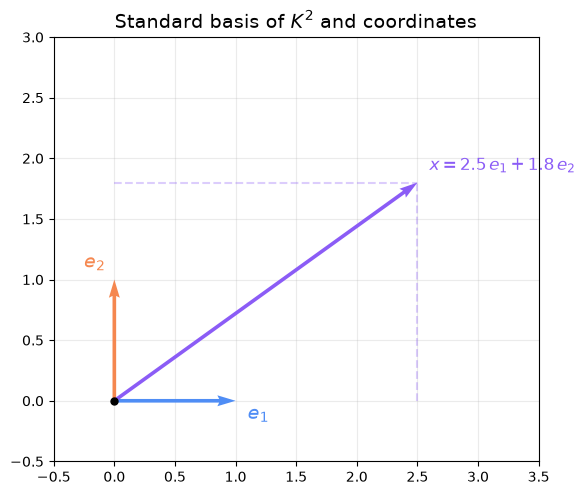

In [2]:

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

# Standard basis in R²
ax.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1,
          color='#4f8df5', linewidth=2.5, zorder=5)
ax.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1,
          color='#f5874f', linewidth=2.5, zorder=5)
ax.text(1.1, -0.15, '$e_1$', fontsize=14, color='#4f8df5', fontweight='bold')
ax.text(-0.25, 1.1, '$e_2$', fontsize=14, color='#f5874f', fontweight='bold')

# A general vector as linear combination
x1, x2 = 2.5, 1.8
ax.quiver(0, 0, x1, x2, angles='xy', scale_units='xy', scale=1,
          color='#8b5cf6', linewidth=2.5, zorder=5)
ax.text(x1 + 0.1, x2 + 0.1, f'$x = {x1}\,e_1 + {x2}\,e_2$',
        fontsize=12, color='#8b5cf6')

# Dashed projections
ax.plot([x1, x1], [0, x2], '--', color='#8b5cf6', alpha=0.3)
ax.plot([0, x1], [x2, x2], '--', color='#8b5cf6', alpha=0.3)

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.25)
ax.set_title('Standard basis of $K^2$ and coordinates', fontsize=14)
ax.plot(0, 0, 'ko', markersize=5, zorder=6)

plt.tight_layout()
plt.show()


### 7\.2\. The Space of All Polynomials is Infinite-Dimensional

Let $\mathbb{R}[x]$ denote the set of all polynomials with real coefficients (of any degree). This is a vector space over $\mathbb{R}$, but it is **not** finite-dimensional.

::: {.callout-tip collapse="true"}
## Proof: $\mathbb{R}[x]$ is Infinite-Dimensional

Suppose for contradiction that $\mathbb{R}[x]$ is finite-dimensional. Then there exist finitely many polynomials $p_1, \dots, p_n$ spanning all of $\mathbb{R}[x]$. Let $d$ be the maximum of $\deg(p_1), \dots, \deg(p_n)$. Any linear combination of $p_1, \dots, p_n$ has degree at most $d$. But $x^{d+1} \in \mathbb{R}[x]$ has degree $d + 1 > d$ and cannot be expressed as such a combination. Contradiction.

$\blacksquare$
:::

---

### 7\.3\. Polynomials of Degree $\le d$ Have Dimension $d+1$

The space $P_d = \{a_0 + a_1 x + \cdots + a_d x^d \mid a_i \in \mathbb{R}\}$ is finite-dimensional with

$$\dim(P_d) = d + 1$$

A basis is $\{1, x, x^2, \dots, x^d\}$, since every polynomial of degree $\le d$ is a unique linear combination $a_0 \cdot 1 + a_1 \cdot x + \cdots + a_d \cdot x^d$.


## 8\. Every Finite-Dimensional Space is Isomorphic to $K^n$

::: {#prp-fin-dim-isomorphic-Kn}
## Isomorphism with $K^n$

If $V$ is an $n$-dimensional vector space over $K$, then $V \cong K^n$. That is, there exists a [linear isomorphism](vector-spaces.ipynb#def-linear-isomorphism) $T: V \to K^n$.
:::

::: {.callout-tip collapse="true"}
## Proof of @prp-fin-dim-isomorphic-Kn

Choose a basis $\{v_1, \dots, v_n\}$ for $V$. Every $x \in V$ has a unique representation:

$$x = x_1 v_1 + x_2 v_2 + \cdots + x_n v_n$$

Define $T: V \to K^n$ by:

$$T(x) = (x_1, x_2, \dots, x_n)$$

**Well-defined and injective.** Suppose $T(x) = T(y)$, i.e., $(x_1, \dots, x_n) = (y_1, \dots, y_n)$. Then:

$$(x_1 - y_1)v_1 + \cdots + (x_n - y_n)v_n = 0$$

By linear independence of $\{v_1, \dots, v_n\}$, all $x_i - y_i = 0$, so $x = y$. This simultaneously proves that $T$ is injective and that the coordinate representation is unique.

**Surjective.** For any $(c_1, \dots, c_n) \in K^n$, the element $x = c_1 v_1 + \cdots + c_n v_n \in V$ satisfies $T(x) = (c_1, \dots, c_n)$.

**Preserves addition.**

$$T(x + y) = T\bigl((x_1+y_1)v_1 + \cdots + (x_n+y_n)v_n\bigr) = (x_1+y_1, \dots, x_n+y_n) = T(x) + T(y)$$

**Preserves scalar multiplication.**

$$T(cx) = T\bigl((cx_1)v_1 + \cdots + (cx_n)v_n\bigr) = (cx_1, \dots, cx_n) = c\,T(x)$$

$\blacksquare$
:::

::: {.callout-warning}
## The Isomorphism Depends on the Choice of Basis
The isomorphism $T$ is **not** canonical — it depends on which basis $\{v_1, \dots, v_n\}$ you choose. Different bases give different isomorphisms. For example, the space of $2 \times 2$ real matrices is $4$-dimensional and isomorphic to $\mathbb{R}^4$, but there is no single "natural" way to order the four entries. This is why it is often better to work with abstract vector spaces rather than forcibly identifying everything with $K^n$.
:::